In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [6]:
data = [
    ["Dacia", 4, 3, 5, 3, 4],
    ["BMW", 5, 5, 5, 5, 5],
    ["Kia", 3, 4, 4, 3, 4],
    ["Mercedes", 5, 5, 4, 5, 5],
    ["Dacia", 2, 3, 3, 2, 3],
    ["BMW", 4, 5, 4, 5, 5],
    ["Kia", 3, 4, 5, 3, 4],
    ["Mercedes", 5, 5, 5, 5, 5],
    ["Dacia", 4, 4, 3, 3, 4],
    ["BMW", 5, 5, 5, 4, 5],
    ["Kia", 4, 3, 4, 3, 4],
    ["Mercedes", 5, 5, 5, 5, 5],
    ["Dacia", 3, 3, 4, 3, 3],
    ["BMW", 5, 4, 5, 5, 5],
    ["Kia", 3, 3, 3, 3, 3],
    ["Mercedes", 5, 5, 5, 4, 5],
    ["Dacia", 4, 4, 3, 3, 4],
    ["BMW", 5, 5, 4, 5, 5],
    ["Kia", 4, 4, 4, 3, 4],
    ["Mercedes", 5, 5, 5, 5, 5],
    ["Dacia", 3, 3, 4, 2, 3],
    ["BMW", 5, 5, 5, 4, 5],
    ["Kia", 3, 4, 3, 3, 3],
    ["Mercedes", 5, 5, 5, 5, 5],
    ["Dacia", 2, 3, 2, 2, 2],
    ["BMW", 5, 4, 5, 5, 5],
    ["Kia", 3, 3, 4, 3, 3],
    ["Mercedes", 5, 5, 4, 5, 5],
    ["Dacia", 4, 3, 4, 3, 4],
    ["Kia", 4, 4, 4, 4, 4],
]

df = pd.DataFrame(data, columns=[
    "Brand", "Polite Driver", "Cleanliness", "Punctuality", "Ride Comfort", "Overall Impression"
])

df.to_csv("taxis_marks.csv")

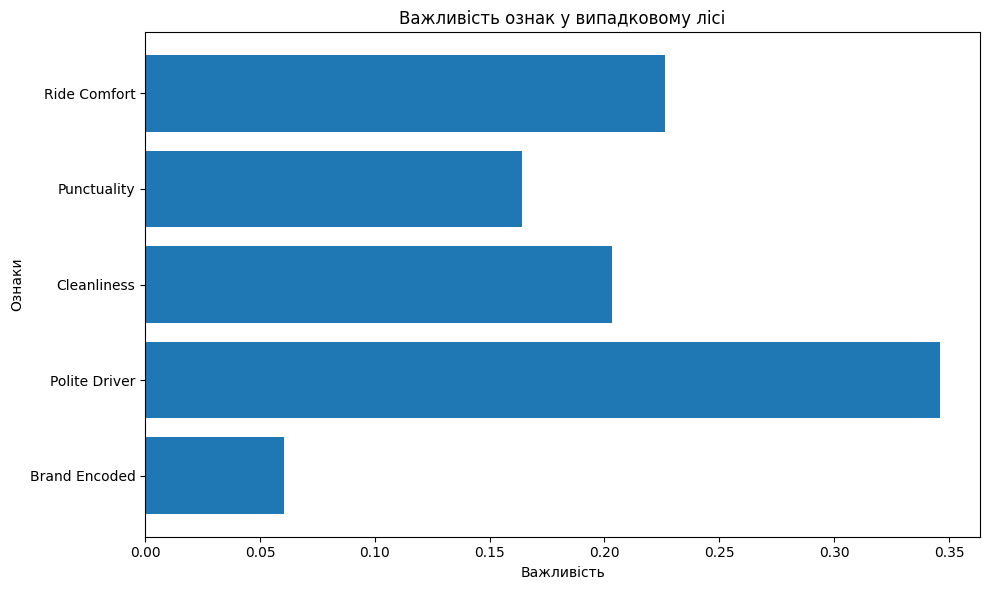

              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [29]:
df = pd.read_csv("taxis_marks.csv")
df["Brand Encoded"] = LabelEncoder().fit_transform(df["Brand"])
X = df[["Brand Encoded","Polite Driver", "Cleanliness", "Punctuality", "Ride Comfort"]]
y = df["Overall Impression"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Важливість")
plt.ylabel("Ознаки")
plt.title("Важливість ознак у випадковому лісі")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))